In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import vector

vector.register_awkward()
hep.style.use("CMS")

In [2]:
data_dir = "/home/tandrade/Flavour_Anomalies/Data/final_mc_bu_skim.root"
tree_name = "tree_ML"
file = uproot.open(data_dir)
tree = file[tree_name]

In [3]:
for branche in tree.keys():
    if "mll" in branche:
        print(branche)

BToTrkTrkMuMu_mll_fullfit_good


In [4]:
tree.keys()

['Track_ptErr_trk2_good',
 'Muon_miniPFRelIso_all_l2_good',
 'nBPHGenPart',
 'BPHGenPart_phi',
 'BToTrkTrkMuMu_vtx_z_good',
 'BToTrkTrkMuMu_fit_trk1_pt_good',
 'Muon_ip3d_l1_good',
 'BToTrkTrkMuMu_vtx_cyx_good',
 'Muon_bestTrackType_l2_good',
 'Muon_dz_l1_good',
 'Muon_miniPFRelIso_chg_l2_good',
 'Muon_pnScore_tau_l2_good',
 'Muon_pdgId_l2_good',
 'BToTrkTrkMuMu_pdgId_good',
 'Muon_isGlobal_l2_good',
 'BToTrkTrkMuMu_eta_trk1_good',
 'Track_covLamPhi_trk2_good',
 'BToTrkTrkMuMu_pt_l2_good',
 'BToTrkTrkMuMu_charge_l1_good',
 'Muon_pnScore_prompt_l1_good',
 'Track_genPartIdx_trk1_good',
 'Track_isPacked_trk1_good',
 'Muon_dxyErr_l2_good',
 'Muon_pt_l2_good',
 'BToTrkTrkMuMu_trk2_svip2d_good',
 'BToTrkTrkMuMu_trk1_iso04_good',
 'Muon_ipLengthSig_l1_good',
 'DiTrack_l_xy_good',
 'Pileup_gpudensity',
 'HLT_DoubleMu4_3_Bs',
 'event',
 'Muon_multiIsoId_l2_good',
 'BToTrkTrkMuMu_pt_trk2_good',
 'Muon_genPartFlav_l1_good',
 'Muon_pnScore_heavy_l2_good',
 'Muon_jetPtRelv2_l2_good',
 'BToTrkTrkMuM

In [5]:
branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l1_eta_good", "BToTrkTrkMuMu_fit_l1_phi_good",
    "BToTrkTrkMuMu_fit_l2_pt_good", "BToTrkTrkMuMu_fit_l2_eta_good", "BToTrkTrkMuMu_fit_l2_phi_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk1_eta_good", "BToTrkTrkMuMu_fit_trk1_phi_good",
    "BToTrkTrkMuMu_fit_trk2_pt_good", "BToTrkTrkMuMu_fit_trk2_eta_good", "BToTrkTrkMuMu_fit_trk2_phi_good",
    "BToTrkTrkMuMu_mll_fullfit_good", "Track_genPartIdx_trk1_good"
]

branches = tree.arrays(branches_to_load, library="ak")

In [6]:
M_MU = 0.105658
M_K  = 0.493677

p4_l1 = ak.zip(
    {"pt": branches["BToTrkTrkMuMu_fit_l1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l1_eta_good"], 
     "phi": branches["BToTrkTrkMuMu_fit_l1_phi_good"], "mass": M_MU},
    with_name="Momentum4D"
)
p4_l2 = ak.zip(
    {"pt": branches["BToTrkTrkMuMu_fit_l2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l2_eta_good"], 
     "phi": branches["BToTrkTrkMuMu_fit_l2_phi_good"], "mass": M_MU},
    with_name="Momentum4D"
)

p4_trk1 = ak.zip(
    {"pt": branches["BToTrkTrkMuMu_fit_trk1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk1_eta_good"], 
     "phi": branches["BToTrkTrkMuMu_fit_trk1_phi_good"], "mass": M_K},
    with_name="Momentum4D"
)
p4_trk2 = ak.zip(
    {"pt": branches["BToTrkTrkMuMu_fit_trk2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk2_eta_good"], 
     "phi": branches["BToTrkTrkMuMu_fit_trk2_phi_good"], "mass": M_K},
    with_name="Momentum4D"
)

In [7]:
dimuon_mass = ak.flatten((p4_l1 + p4_l2).mass, axis=None)
p4_Bplus  = p4_l1 + p4_l2 + p4_trk1
p4_Bminus = p4_l1 + p4_l2 + p4_trk2

p4_Bplus_mass = ak.flatten(p4_Bplus.mass, axis=None)
p4_Bpminus_mass = ak.flatten(p4_Bminus.mass, axis=None)

mask_jpsi = (dimuon_mass > 2.95) & (dimuon_mass < 3.25)
p4_Bplus_mass_filtered = p4_Bplus_mass[mask_jpsi]
p4_Bpminus_mass_filtered = p4_Bpminus_mass[mask_jpsi]

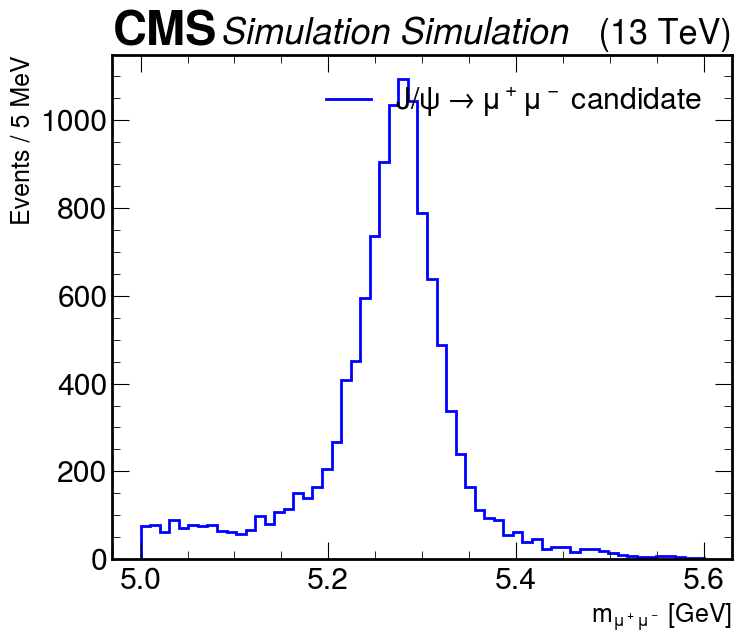

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))

bins = np.linspace(5.0, 5.6, 60) 

hep.histplot(
    np.histogram(p4_Bplus_mass_filtered, bins=bins)[0],
    bins=bins,
    histtype="step",
    color="blue",
    label=r"$J/\psi \to \mu^+\mu^-$ candidate", 
    lw=2
)

ax.set_xlabel(r"$m_{\mu^+\mu^-}$ [GeV]", fontsize=18)
ax.set_ylabel("Events / 5 MeV", fontsize=18)
ax.legend(loc="upper right")
hep.cms.label("Simulation", data=False, ax=ax)

plt.tight_layout()
plt.show()

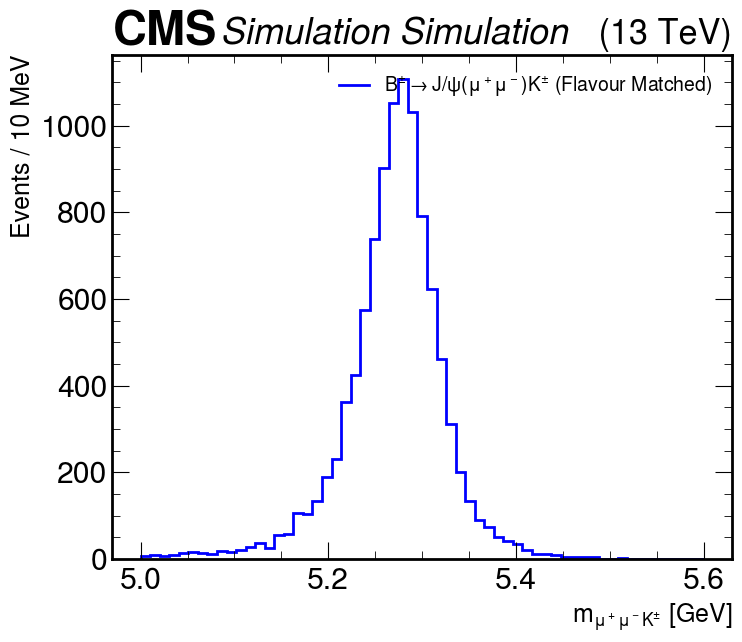

In [9]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import vector

vector.register_awkward()
hep.style.use("CMS")

# --- 1. Carregamento dos Dados ---
data_dir = "/home/tandrade/Flavour_Anomalies/Data/final_mc_bu_skim.root"
tree_name = "tree_ML"
file = uproot.open(data_dir)
tree = file[tree_name]

# Adicionamos a variável Track_genPartFlav!
branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l1_eta_good", "BToTrkTrkMuMu_fit_l1_phi_good",
    "BToTrkTrkMuMu_fit_l2_pt_good", "BToTrkTrkMuMu_fit_l2_eta_good", "BToTrkTrkMuMu_fit_l2_phi_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk1_eta_good", "BToTrkTrkMuMu_fit_trk1_phi_good",
    "BToTrkTrkMuMu_fit_trk2_pt_good", "BToTrkTrkMuMu_fit_trk2_eta_good", "BToTrkTrkMuMu_fit_trk2_phi_good",
    "Muon_genPartIdx_l1_good", "Muon_genPartIdx_l2_good",
    "GenPart_pdgId", 
    "Track_genPartFlav_trk1_good", "Track_genPartFlav_trk2_good" # <-- A CHAVE ESTÁ AQUI
]

branches = tree.arrays(branches_to_load, library="ak")

# --- 2. Criação dos Quadrivetores Reconstruídos ---
M_MU = 0.105658
M_K  = 0.493677

p4_l1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l1_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_l1_phi_good"], "mass": M_MU}, with_name="Momentum4D")
p4_l2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l2_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_l2_phi_good"], "mass": M_MU}, with_name="Momentum4D")
p4_trk1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk1_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_trk1_phi_good"], "mass": M_K}, with_name="Momentum4D")
p4_trk2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk2_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_trk2_phi_good"], "mass": M_K}, with_name="Momentum4D")

# --- 3. Truth Matching ---

# A. Múons (Usamos GenPart padrão por índice, pois funcionou bem)
gen_pdgId = branches["GenPart_pdgId"]

def is_true_muon(gen_pdgIds, reco_gen_indices):
    n_gen = ak.num(gen_pdgIds)
    valid_mask = (reco_gen_indices >= 0) & (reco_gen_indices < n_gen)
    safe_indices = ak.where(valid_mask, reco_gen_indices, 0)
    matched_pdgIds = gen_pdgIds[safe_indices]
    return valid_mask & (abs(matched_pdgIds) == 13)

is_true_muons = is_true_muon(gen_pdgId, branches["Muon_genPartIdx_l1_good"]) & is_true_muon(gen_pdgId, branches["Muon_genPartIdx_l2_good"])

# B. Traços (Kaons) - Usando a variável de Flavour!
# NOTA IMPORTANTE: Para saber EXATAMENTE qual o número que significa "Kaon Verdadeiro do Sinal"
# na sua amostra, precisaremos ver os valores que genPartFlav está assumindo.
# Por padrão, vamos assumir que qualquer coisa diferente de 0 é um traço real vindo de um decaimento.
# (Se precisar ser mais específico, faremos um print no próximo passo).

is_true_K1 = branches["Track_genPartFlav_trk1_good"] != 0
is_true_K2 = branches["Track_genPartFlav_trk2_good"] != 0

# --- 4. Reconstrução Combinada ---
mask_B_trk1 = is_true_muons & is_true_K1
mask_B_trk2 = is_true_muons & is_true_K2

dimuon_mass = (p4_l1 + p4_l2).mass
p4_Bplus  = p4_l1 + p4_l2 + p4_trk1
p4_Bminus = p4_l1 + p4_l2 + p4_trk2

# Aplicamos os filtros de Gen Matching nas massas
Bplus_mass_matched = p4_Bplus.mass[mask_B_trk1]
Bminus_mass_matched = p4_Bminus.mass[mask_B_trk2]

dimuon_mass_trk1_matched = dimuon_mass[mask_B_trk1]
dimuon_mass_trk2_matched = dimuon_mass[mask_B_trk2]

# Filtro de massa do J/psi
mask_jpsi_trk1 = (dimuon_mass_trk1_matched > 2.95) & (dimuon_mass_trk1_matched < 3.25)
p4_Bplus_mass_filtered = Bplus_mass_matched[mask_jpsi_trk1]

mask_jpsi_trk2 = (dimuon_mass_trk2_matched > 2.95) & (dimuon_mass_trk2_matched < 3.25)
p4_Bminus_mass_filtered = Bminus_mass_matched[mask_jpsi_trk2]

# Achatamos os arrays para o plot final
p4_B_mass_final = ak.flatten(
    ak.concatenate([p4_Bplus_mass_filtered, p4_Bminus_mass_filtered], axis=-1), 
    axis=None
)

# --- 5. Plotting ---
fig, ax = plt.subplots(figsize=(8, 7))
bins = np.linspace(5.0, 5.6, 60) 

hep.histplot(
    np.histogram(p4_B_mass_final, bins=bins)[0],
    bins=bins,
    histtype="step",
    color="blue",
    label=r"$B^{\pm} \to J/\psi (\mu^+\mu^-) K^{\pm}$ (Flavour Matched)", 
    lw=2
)

ax.set_xlabel(r"$m_{\mu^+\mu^-K^{\pm}}$ [GeV]", fontsize=18)
ax.set_ylabel("Events / 10 MeV", fontsize=18)
ax.legend(loc="upper right", fontsize=14)
hep.cms.label("Simulation", data=False, ax=ax)

plt.tight_layout()
plt.show()

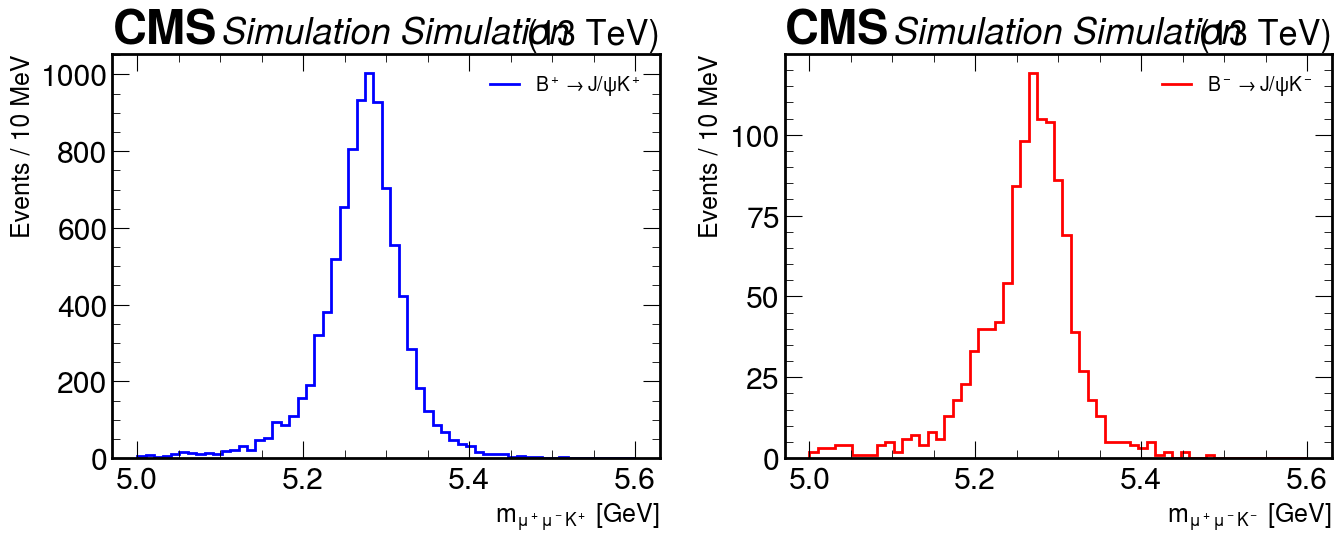

In [10]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import vector

vector.register_awkward()
hep.style.use("CMS")

# --- 1. Carregamento dos Dados ---
data_dir = "/home/tandrade/Flavour_Anomalies/Data/final_mc_bu_skim.root"
tree_name = "tree_ML"
file = uproot.open(data_dir)
tree = file[tree_name]

branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l1_eta_good", "BToTrkTrkMuMu_fit_l1_phi_good",
    "BToTrkTrkMuMu_fit_l2_pt_good", "BToTrkTrkMuMu_fit_l2_eta_good", "BToTrkTrkMuMu_fit_l2_phi_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk1_eta_good", "BToTrkTrkMuMu_fit_trk1_phi_good",
    "BToTrkTrkMuMu_fit_trk2_pt_good", "BToTrkTrkMuMu_fit_trk2_eta_good", "BToTrkTrkMuMu_fit_trk2_phi_good",
    "Muon_genPartIdx_l1_good", "Muon_genPartIdx_l2_good",
    "GenPart_pdgId", 
    "Track_genPartFlav_trk1_good", "Track_genPartFlav_trk2_good",
    "Track_charge_trk1_good", "Track_charge_trk2_good" # <- Adicionamos a carga dos traços
]

branches = tree.arrays(branches_to_load, library="ak")

# --- 2. Criação dos Quadrivetores Reconstruídos ---
M_MU = 0.105658
M_K  = 0.493677

p4_l1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l1_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_l1_phi_good"], "mass": M_MU}, with_name="Momentum4D")
p4_l2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l2_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_l2_phi_good"], "mass": M_MU}, with_name="Momentum4D")
p4_trk1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk1_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_trk1_phi_good"], "mass": M_K}, with_name="Momentum4D")
p4_trk2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk2_eta_good"], "phi": branches["BToTrkTrkMuMu_fit_trk2_phi_good"], "mass": M_K}, with_name="Momentum4D")

# Cargas dos traços
charge_trk1 = branches["Track_charge_trk1_good"]
charge_trk2 = branches["Track_charge_trk2_good"]

# --- 3. Truth Matching ---
gen_pdgId = branches["GenPart_pdgId"]

def is_true_muon(gen_pdgIds, reco_gen_indices):
    n_gen = ak.num(gen_pdgIds)
    valid_mask = (reco_gen_indices >= 0) & (reco_gen_indices < n_gen)
    safe_indices = ak.where(valid_mask, reco_gen_indices, 0)
    matched_pdgIds = gen_pdgIds[safe_indices]
    return valid_mask & (abs(matched_pdgIds) == 13)

is_true_muons = is_true_muon(gen_pdgId, branches["Muon_genPartIdx_l1_good"]) & is_true_muon(gen_pdgId, branches["Muon_genPartIdx_l2_good"])

is_true_K1 = branches["Track_genPartFlav_trk1_good"] != 0
is_true_K2 = branches["Track_genPartFlav_trk2_good"] != 0

mask_B_trk1 = is_true_muons & is_true_K1
mask_B_trk2 = is_true_muons & is_true_K2

# --- 4. Reconstrução e Filtro J/psi ---
dimuon_mass = (p4_l1 + p4_l2).mass
mass_trk1 = (p4_l1 + p4_l2 + p4_trk1).mass
mass_trk2 = (p4_l1 + p4_l2 + p4_trk2).mass

mask_jpsi = (dimuon_mass > 2.95) & (dimuon_mass < 3.25)

# Combinação final de máscaras: J/psi Mass Window + Truth Matching
final_mask_trk1 = mask_jpsi & mask_B_trk1
final_mask_trk2 = mask_jpsi & mask_B_trk2

# Extraímos as massas e as cargas dos candidatos que passaram em todos os filtros
mass_valid_trk1 = mass_trk1[final_mask_trk1]
chg_valid_trk1 = charge_trk1[final_mask_trk1]

mass_valid_trk2 = mass_trk2[final_mask_trk2]
chg_valid_trk2 = charge_trk2[final_mask_trk2]

# Concatenamos tudo em arrays unidimensionais únicos
all_masses = ak.flatten(ak.concatenate([mass_valid_trk1, mass_valid_trk2], axis=-1), axis=None)
all_charges = ak.flatten(ak.concatenate([chg_valid_trk1, chg_valid_trk2], axis=-1), axis=None)

# --- SEPARAÇÃO PELA CARGA DO KAON ---
# K+ tem carga > 0, K- tem carga < 0
mass_Bplus_Kplus = all_masses[all_charges > 0]
mass_Bminus_Kminus = all_masses[all_charges < 0]

# --- 5. Plotting Lado a Lado ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6)) # 1 linha, 2 colunas
bins = np.linspace(5.0, 5.6, 60) 

# Painel Esquerdo: m(mu mu K+)
hep.histplot(
    np.histogram(mass_Bplus_Kplus, bins=bins)[0],
    bins=bins,
    histtype="step",
    color="blue",
    label=r"$B^+ \to J/\psi K^+$", 
    lw=2,
    ax=ax[0]
)
ax[0].set_xlabel(r"$m_{\mu^+\mu^-K^+}$ [GeV]", fontsize=18)
ax[0].set_ylabel("Events / 10 MeV", fontsize=18)
ax[0].legend(loc="upper right", fontsize=14)
hep.cms.label("Simulation", data=False, ax=ax[0])

# Painel Direito: m(mu mu K-)
hep.histplot(
    np.histogram(mass_Bminus_Kminus, bins=bins)[0],
    bins=bins,
    histtype="step",
    color="red",
    label=r"$B^- \to J/\psi K^-$", 
    lw=2,
    ax=ax[1]
)
ax[1].set_xlabel(r"$m_{\mu^+\mu^-K^-}$ [GeV]", fontsize=18)
ax[1].set_ylabel("Events / 10 MeV", fontsize=18)
ax[1].legend(loc="upper right", fontsize=14)
hep.cms.label("Simulation", data=False, ax=ax[1])

plt.tight_layout()
plt.show()